In [2]:
import pandas as pd
import numpy as np

Datasets = []
PREDICTORS = ["PwmD", "PwmE", "WdRef", "WeRef"]   
TARGET_INT = ["Theta", "X", "Y"]  
TARGET = ["DeltaTheta", "DeltaX", "DeltaY"]
     
TS = 0.07

In [3]:
for i in range(4):
    Dataset = pd.read_excel(f"./../../RotedData/Data.xlsx", f"D{i+1}")   
    Datasets.append(Dataset)

for i in range(2):   
    Dataset = pd.read_csv(f"./../../Data/Data{i + 1}.csv")  
    Datasets.append(Dataset)
    
    
for i in range(len(Datasets)):
    Dataset = Datasets[i].copy()

    for var in TARGET_INT:
        Dataset[f"Delta{var}"] = (Dataset[var].shift(-1) - Dataset[var]) / TS
    
    for var in PREDICTORS:
        Dataset[f"s{var}"] = (Dataset[var].shift(-1) + Dataset[var]) 
    
    for var in PREDICTORS:
        Dataset[f"d{var}"] = (Dataset[var].shift(-1) - Dataset[var])  
            
    Dataset = Dataset.dropna(subset=[f"Delta{var}" for var in TARGET_INT])

    Datasets[i] = Dataset

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# Análise de Lags
# ==============================
def TimeStepsAnalysis(n_lags, preds, targs, data):
    
    lagged_data = pd.DataFrame()

    for col in preds:
        for lag in range(1, n_lags + 1):
            lagged_data[f"{col}_lag{lag}"] = data[col].shift(lag)

    # adicionar targets
    for t in targs:
        lagged_data[t] = data[t]

    # remover NaN
    lagged_data = lagged_data.dropna()


    # ==============================
    # Correlação
    # ==============================

    corr = lagged_data.corr()

    plt.figure(figsize=(12,6))

    sns.heatmap(
        corr[targs].T,
        annot=True,
        cmap="Blues",
        center=0
    )

    plt.title("Correlação entre variáveis defasadas e saídas")

    plt.tight_layout()

    plt.show()

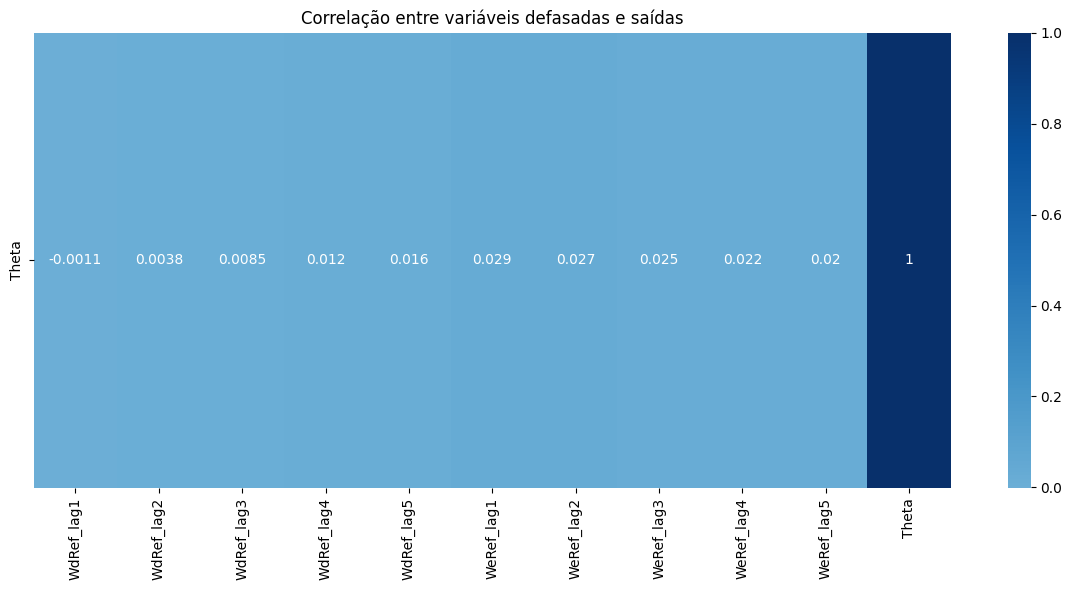

In [5]:
TimeStepsAnalysis(n_lags=5, preds=["WdRef", "WeRef"], targs=["Theta"], data=Datasets[0])

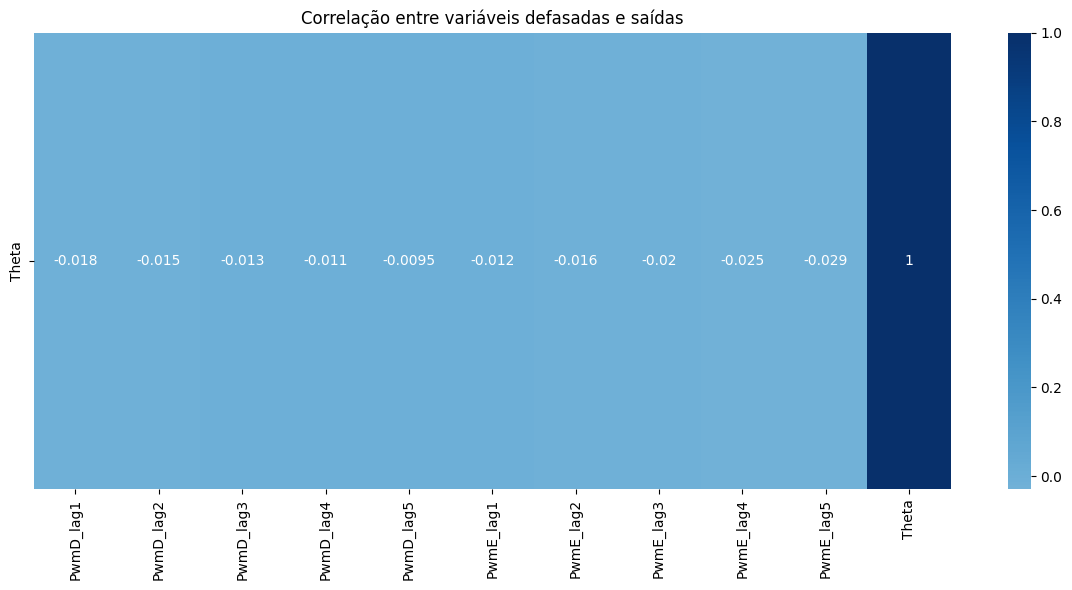

In [6]:
TimeStepsAnalysis(n_lags=5, preds=["PwmD", "PwmE"], targs=["Theta"], data=Datasets[0])